# Assignment 2. Sensitivity Analysis — Which inputs Matter?
**Course:** EPA141A Model Based Decision Making — Delft University of Technology  
**Model:** JUSTICE  

---

## Learning Outcomes

After completing this assignment you will be able to:
1. Explain the purpose of sensitivity analysis and when to apply it.
2. Compute **Extra-Trees feature importance** using the EMA Workbench `feature_scoring` module.
3. Run a **Morris elementary effects** analysis with SALib and interpret **μ\*** and **σ**.
4. Compare sensitivity rankings under **no abatement** vs. **moderate abatement** and explain
   what policy-conditional sensitivity means for decision-making.


---

## Background

Assignment 1 showed that four uncertain parameters produce a wide spread in all four outcomes.
Sensitivity analysis (SA) answers the follow-up question: **which inputs are responsible for that spread?**

We use two complementary methods:

**Extra-Trees feature importance** (EMA Workbench `feature_scoring`)  
Fits an ensemble of extremely randomised regression trees on the LHS ensemble.
Reports how much each parameter reduces prediction variance across all trees.

**Morris elementary effects** (via `Samplers.MORRIS`)  
In this version, the Morris design is generated through EMA Workbench's built-in
`MorrisSampler`. The analysis step still uses SALib's `morris_analyze.analyze()`.

> Reference: [EMA Workbench SALib samplers API](https://emaworkbench.readthedocs.io/en/latest/ema_documentation/em_framework/salib_samplers.html)


## Setup — Imports and model configuration

The cell below imports all required packages (including SALib for Morris and EMA Workbench for Extra-Trees), configures logging, and defines the shared name lists for outcomes, parameters, and policies used throughout the analysis.

In [1]:
import os, sys
try:
    _NOTEBOOK_DIR = os.path.dirname(os.path.abspath(__vsc_ipynb_file__))
except NameError:
    _NOTEBOOK_DIR = os.path.abspath('.')
_justice_root = os.path.normpath(os.path.join(_NOTEBOOK_DIR, '../JUSTICE-main'))
_PLOTS_DIR = os.path.join(_NOTEBOOK_DIR, 'plots')
os.makedirs(_PLOTS_DIR, exist_ok=True)
if _justice_root not in sys.path:
    sys.path.insert(0, _justice_root)
os.chdir(_justice_root)

import warnings; warnings.filterwarnings('ignore')
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from SALib.analyze import morris as morris_analyze
from ema_workbench import (
    Model, RealParameter, ScalarOutcome, ArrayOutcome,
    Constant, ema_logging, Sample, SequentialEvaluator,
)
from ema_workbench.em_framework.evaluators import Samplers
from ema_workbench.em_framework.salib_samplers import get_SALib_problem
from ema_workbench.analysis import feature_scoring
from justice.model import JUSTICE
from justice.util.enumerations import WelfareFunction
from justice.objectives.objective_functions import years_above_temperature_threshold

ema_logging.log_to_stderr(logging.WARNING)

OBJECTIVES   = ['welfare', 'years_above_temperature_threshold',
                'welfare_loss_damage', 'welfare_loss_abatement']
PARAMS       = ['rho', 'eta', 'delta', 'ecs_ensemble']
PARAMS_MORRIS = ['delta', 'eta', 'rho']   # alphabetical; ecs_ensemble excluded
POLICY_NAMES = ['no_abatement', 'moderate_abatement']
palette      = {'no_abatement': 'steelblue', 'moderate_abatement': 'darkorange'}

print('Imports OK')

Imports OK


---

## Step 1 — Define the model
The model wrapper is identical to Assignment 1: four uncertain parameters plus the `ecr_plateau` lever.

**Task 1.1** — Complete `justice_model` so it:
1. Hard-resets JUSTICE and instantiates it with the given `ecs_ensemble` index.
2. Sets ρ and η on both `model.economy` and `model.welfare_function`.
3. Scales the three damage coefficients by δ.
4. Runs with a uniform ECR equal to `ecr_plateau` across all regions and returns all four scalar outcomes plus the global mean temperature trajectory.

**Task 1.2** — Run the smoke test below and confirm the four outcomes are positive and in plausible ranges.

In [2]:
def justice_model(rho=0.015, eta=1.45, delta=1.0, ecs_ensemble=1, ecr_plateau=0.0):
    JUSTICE.hard_reset()
    ensemble_idx = int(np.round(np.clip(ecs_ensemble, 1, 1001)))
    model = JUSTICE(
        start_year=2015, end_year=2300, timestep=1,
        scenario=2, climate_ensembles=ensemble_idx, stochastic_run=False,
        social_welfare_function=WelfareFunction.UTILITARIAN,
    )
    model.economy.pure_rate_of_social_time_preference                    = float(rho)
    model.economy.elasticity_of_marginal_utility_of_consumption          = float(eta)
    model.welfare_function.pure_rate_of_social_time_preference           = float(rho)
    model.welfare_function.elasticity_of_marginal_utility_of_consumption = float(eta)
    model.damage_function.coefficient_a                  *= float(delta)
    model.damage_function.coefficient_b                  *= float(delta)
    model.damage_function.damage_gdp_ratio_with_gradient *= float(delta)

    ecr = np.full(model.emission_control_rate.shape[:2], float(ecr_plateau))
    model.run(emission_control_rate=ecr, endogenous_savings_rate=True)
    datasets = model.evaluate()

    welfare = float(np.abs(np.squeeze(datasets['welfare'])))
    yat     = float(np.squeeze(
        years_above_temperature_threshold(datasets['global_temperature'], 2.0)
    ))
    _, _, _, wl_dmg = model.welfare_function.calculate_welfare(
        datasets['damage_cost_per_capita'], welfare_loss=True)
    _, _, _, wl_abt = model.welfare_function.calculate_welfare(
        datasets['abatement_cost_per_capita'], welfare_loss=True)
    temp = np.squeeze(datasets['global_temperature'])
    if temp.ndim == 2:
        temp = temp.mean(axis=0)

    return {
        'welfare':                           welfare,
        'years_above_temperature_threshold': yat,
        'welfare_loss_damage':               float(np.abs(np.squeeze(wl_dmg))),
        'welfare_loss_abatement':            float(np.abs(np.squeeze(wl_abt))),
        'temperature_trajectory':            temp.astype(float),
    }

# Smoke test
test = justice_model()
for k, v in test.items():
    if isinstance(v, np.ndarray):
        print(f'  {k}: array shape {v.shape}, range [{v.min():.2f}, {v.max():.2f}]')
    else:
        print(f'  {k}: {v:.4f}')

  welfare: 103.7211
  years_above_temperature_threshold: 259.0000
  welfare_loss_damage: 3980.5410
  welfare_loss_abatement: 74364.1321
  temperature_trajectory: array shape (286,), range [1.20, 6.01]


---

## Step 2 — EMA model setup and LHS ensemble


**Task 2.1** — Wrap `justice_model` in a `Model` object with the same four uncertain
parameters and four scalar outcomes as Assignment 1.

**Task 2.2** — Run 100 LHS scenarios under each policy using `SequentialEvaluator`. This
ensemble is used as input to the Extra-Trees analysis in Step 3.

**Task 2.3** — How does the `welfare_loss_abatement` distribution compare between the
two policies? Explain the difference.



> *Note: The outcome distributions for both policies are fully explored in **Assignment 1**
(Steps 3–4). The key finding there was that `years_above_temperature_threshold` shows the
clearest policy separation (~15 year shift), while `welfare` distributions overlap almost
entirely — policy signal is overwhelmed by parametric uncertainty. SA in this assignment
explains **why** those distributions are wide and which specific inputs drive the spread.*

In [3]:
em_model = Model('JUSTICE', function=justice_model)

em_model.uncertainties = [
    RealParameter('rho',          0.001,    0.030),
    RealParameter('eta',          0.5,      1.5),
    RealParameter('delta',        0.5,      2.0),
    RealParameter('ecs_ensemble', 1,     1001),
]
em_model.levers = []
em_model.outcomes = [
    ScalarOutcome('welfare'),
    ScalarOutcome('years_above_temperature_threshold'),
    ScalarOutcome('welfare_loss_damage'),
    ScalarOutcome('welfare_loss_abatement'),
]

policies = [
    Sample('no_abatement',       ecr_plateau=0.0),
    Sample('moderate_abatement', ecr_plateau=0.4),
]

with SequentialEvaluator(em_model) as evaluator:
    experiments, outcomes = evaluator.perform_experiments(
        scenarios=100, policies=policies)

df_results = pd.DataFrame({k: v for k, v in outcomes.items() if k != 'temperature_trajectory'})
df_results['policy'] = experiments['policy'].values

print(f'experiments shape : {experiments.shape}')
print(f'policy counts     :\n{df_results["policy"].value_counts()}')
display(df_results[OBJECTIVES].describe().round(4))

100%|████████████████████████████████████████| 200/200 [03:16<00:00,  1.02it/s]

experiments shape : (200, 7)
policy counts     :
policy
moderate_abatement    100
no_abatement          100
Name: count, dtype: int64


,welfare,years_above_temperature_threshold,welfare_loss_damage,welfare_loss_abatement
count,200.0000,200.0000,200.0000,200.0000
mean,1037.0685,238.6600,1533.2714,9104.8270
std,1985.7590,15.7242,2230.8976,30224.4951
min,60.6697,177.0000,1.1128,0.5714
25%,240.2537,231.0000,411.5952,75.6209
50%,451.4617,242.0000,850.8372,507.7258
75%,1031.0211,251.0000,1710.3682,2528.8216
max,15301.7787,268.0000,15516.1834,251938.5327


---

## Step 3 — Extra-Trees feature importance

`feature_scoring.get_feature_scores_all(x, y)` fits an `ExtraTreesRegressor` for each
outcome on the LHS ensemble and returns a DataFrame of importances
(rows = parameters, columns = outcomes).

Running the analysis separately for each policy tests whether sensitivity is
**policy-conditional** — i.e., whether the same parameter matters equally under
both no abatement and moderate abatement.

**Task 3.1** — Compute Extra-Trees importances for each policy separately.

**Task 3.2** — Plot the importances as a 2×2 bar-chart grid for each policy (two grids total).

**Task 3.3** — Which parameter dominates `years_above_temperature_threshold`? Is this a
normative or physical uncertainty? What does this imply for climate policy?


--- no_abatement ---
              welfare  years_above_temperature_threshold  welfare_loss_damage  welfare_loss_abatement
0                                                                                                    
delta           0.224                              0.253                0.224                   0.160
ecs_ensemble    0.210                              0.240                0.194                   0.150
eta             0.304                              0.253                0.380                   0.423
rho             0.261                              0.253                0.202                   0.267

--- moderate_abatement ---
              welfare  years_above_temperature_threshold  welfare_loss_damage  welfare_loss_abatement
0                                                                                                    
delta           0.243                              0.234                0.257                   0.235
ecs_ensemble    0.235           

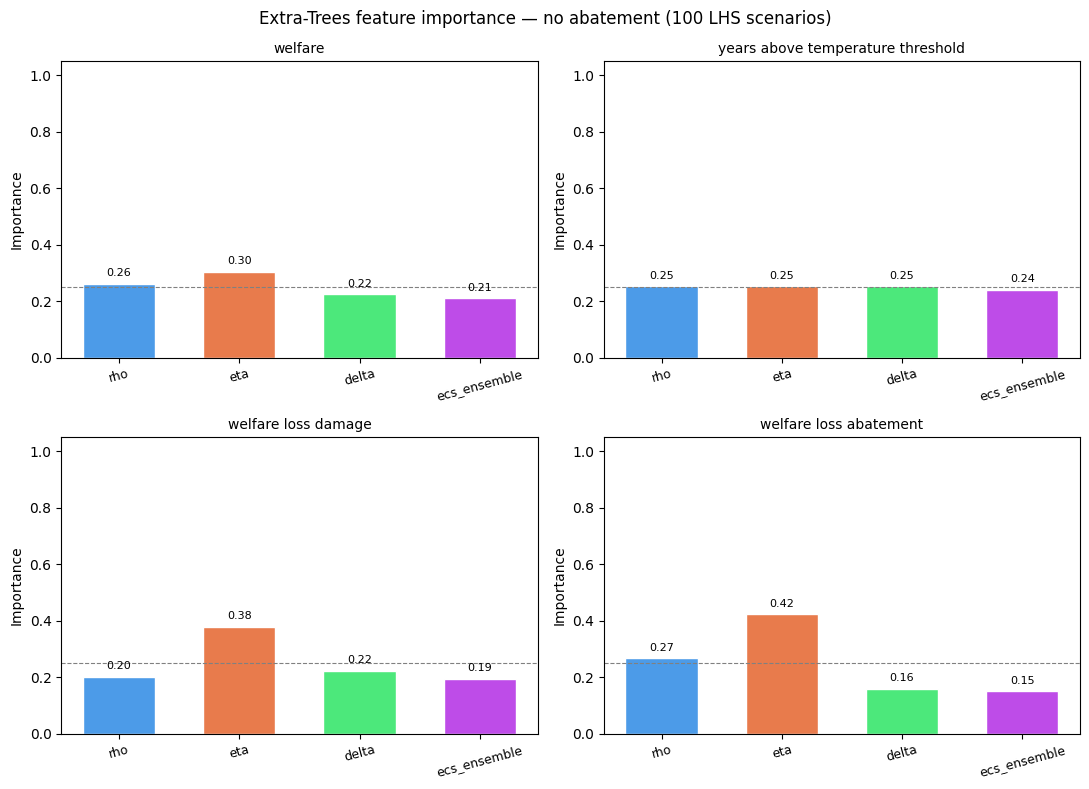

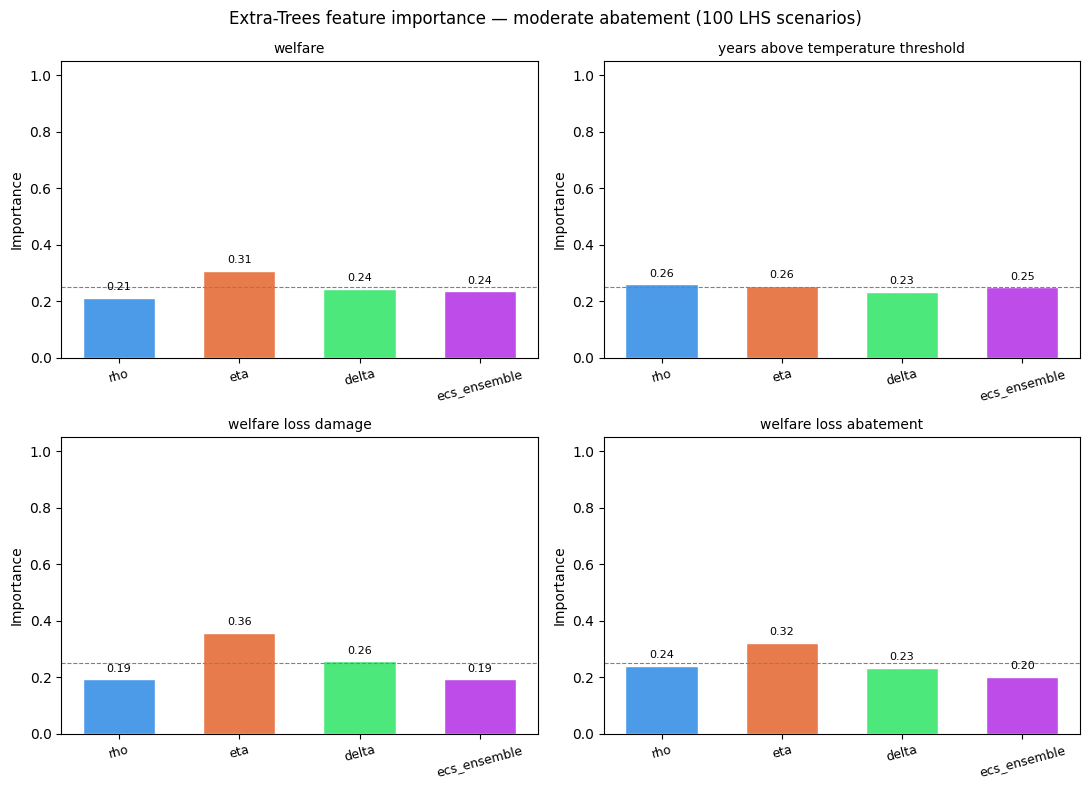

In [4]:
et_scores = {}
for pol in POLICY_NAMES:
    mask      = experiments['policy'] == pol
    x_pol     = experiments[mask][PARAMS]
    y_pol     = {k: outcomes[k][mask] for k in OBJECTIVES}
    et_scores[pol] = feature_scoring.get_feature_scores_all(x_pol, y_pol)
    print(f'\n--- {pol} ---')
    print(et_scores[pol].round(3).to_string())

colors = ['#4C9BE8', '#E87B4C', '#4CE87B', '#BE4CE8']
x = np.arange(len(PARAMS))

for pol in POLICY_NAMES:
    sc = et_scores[pol]
    fig, axes = plt.subplots(2, 2, figsize=(11, 8))
    for ax, obj in zip(axes.flat, OBJECTIVES):
        imp  = sc[obj].reindex(PARAMS).values
        bars = ax.bar(x, imp, color=colors, edgecolor='white', width=0.6)
        ax.set_xticks(x); ax.set_xticklabels(PARAMS, rotation=15, fontsize=9)
        ax.set_ylim(0, 1.05); ax.set_title(obj.replace('_', ' '), fontsize=10)
        ax.set_ylabel('Importance'); ax.axhline(0.25, color='grey', lw=0.8, ls='--')
        for bar, val in zip(bars, imp):
            ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=8)
    fig.suptitle(f'Extra-Trees feature importance — {pol.replace("_", " ")} (100 LHS scenarios)',
                 fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(_PLOTS_DIR, f'a02api_et_{pol}.png'), dpi=150, bbox_inches='tight')
    plt.show()


**How to read this plot — bar chart of feature importances**

Each bar shows how much one parameter reduces prediction variance in the Extra-Trees model
for that outcome. Importances sum to 1 across all parameters within each panel. A tall bar
means that parameter alone explains most of the outcome's variability; a near-zero bar means
the parameter is irrelevant within its sampled range. The dashed horizontal line at 0.25 marks
equal importance across all four parameters — a useful reference for judging dominance.

---

**Interpretation — Extra-Trees bar charts**

- **`ecs_ensemble` dominates `years_above_temperature_threshold`** under both policies. Physical
  warming is determined entirely by the ECS ensemble member; normative parameters (ρ, η, δ) do
  not enter the temperature calculation directly.

- **η dominates welfare outcomes** in both policies. η controls utility curvature — how strongly
  any consumption change translates into welfare loss — making it the most influential parameter
  for all three welfare-based outcomes.

- **δ gains importance under no abatement** relative to moderate abatement: without emission
  control, temperatures rise further, allowing the damage scaling coefficient to explain more
  variance in `welfare_loss_damage`.

- **ρ remains near zero throughout** — its influence on any outcome is negligible within
  the sampled range [0.001, 0.030] compared to η.



## Step 4 — Policy-comparison sensitivity heatmap

A side-by-side heatmap (one panel per policy) puts both ET analyses on the same axes,
making it easy to see which parameters shift in importance between the two policies.
Importances are normalised per column so they sum to 1 within each outcome.

**Task 4.1** — Build the two normalised heatmaps and compare them.

**Task 4.2** — Which parameter gains the most importance under no abatement compared to
moderate abatement? Which loses importance? Explain both changes mechanistically.

**Task 4.3** — What does this imply for a decision-maker who needs to choose between the
two policies under deep uncertainty?

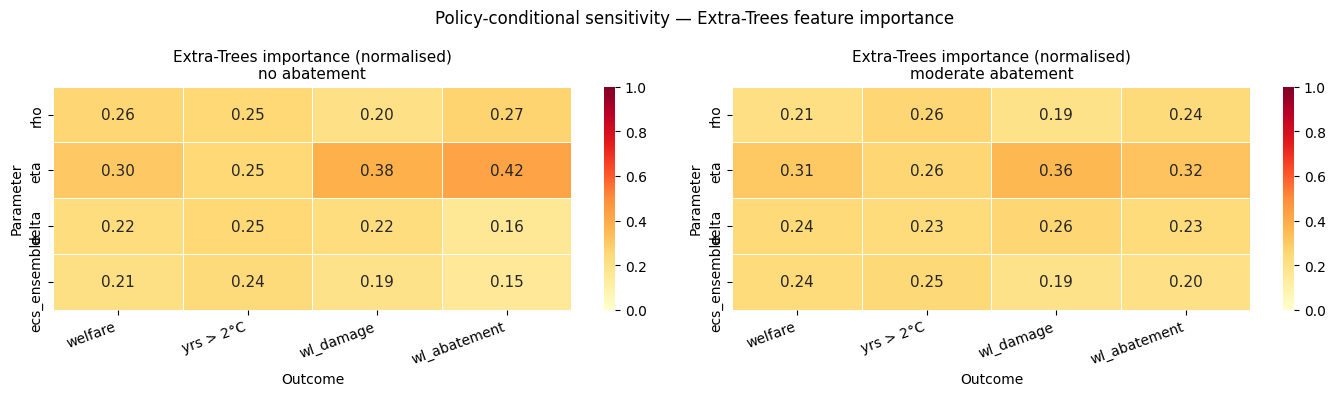

In [8]:
short = [o.replace('years_above_temperature_threshold', 'yrs > 2\u00b0C')
          .replace('welfare_loss_', 'wl_') for o in OBJECTIVES]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, pol in zip(axes, POLICY_NAMES):
    mat      = et_scores[pol].reindex(PARAMS)[OBJECTIVES]
    mat_norm = (mat / mat.sum()).fillna(0)
    sns.heatmap(mat_norm, annot=True, fmt='.2f', cmap='YlOrRd', vmin=0, vmax=1,
                linewidths=0.5, ax=ax, annot_kws={'size': 11})
    ax.set_title(f'Extra-Trees importance (normalised)\n{pol.replace("_", " ")}',
                 fontsize=11)
    ax.set_xlabel('Outcome'); ax.set_ylabel('Parameter')
    ax.set_xticklabels(short, rotation=20, ha='right')

fig.suptitle('Policy-conditional sensitivity — Extra-Trees feature importance', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(_PLOTS_DIR, 'a02api_sensitivity_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

**How to read this plot — sensitivity heatmap**

Each cell shows the importance of one parameter (row) for one outcome (column), normalised so that each column sums to 1. A value near 1.0 means that parameter alone explains nearly all outcome variance; a value near 0 means it has no detectable influence. Comparing the two heatmaps side by side shows which parameters gain or lose importance under different policies — a direct test of policy-conditional sensitivity.

**Interpretation — Policy-comparison heatmap**

No single parameter dominates years_above_temperature_threshold: all four parameters score ~0.24–0.26 under both policies, indicating diffuse sensitivity. Temperature threshold exceedance cannot be attributed to one dominant source of uncertainty at this sample size.

eta is the strongest driver of welfare-loss outcomes under both policies, scoring highest for wl_damage (0.38 / 0.36) and wl_abatement (0.42 / 0.32). This reflects its direct role as the curvature parameter of the utility function, which amplifies or dampens how losses are weighted.

eta's advantage over other parameters narrows under moderate abatement for wl_abatement (dropping from 0.42 to 0.32), while δ rises from 0.16 to 0.23. When abatement partially constrains temperature, the damage scaling parameter contributes more to welfare-loss variance.

rho contributes non-negligibly across all outcomes (0.19–0.27), comparable to δ and ecs_ensemble. It is not a negligible driver within the range [0.001, 0.030].

ecs_ensemble is the weakest driver overall, consistently scoring at or below the other parameters — particularly for wl_damage (0.19 under both policies) and wl_abatement (0.15 / 0.20). This is counterintuitive but may reflect that 100 LHS draws sample only a fraction of the 1–1001 climate ensemble index, limiting the trees' ability to detect its effect.

---

## Step 5 — Morris elementary effects 

The **Morris method** (elementary effects) is a global screening approach that perturbs one input at a time by a finite step and computes the resulting “elementary effect” on the output. For each input, it summarizes these effects by the mean of their absolute values, μ*, as a robust importance measure (always non-negative), and by their standard deviation, σ, as an indicator of non-linearity and interaction with other parameters.


The EMA Workbench use SALib and provides `Samplers.MORRIS` — a `MorrisSampler` that generates the
Morris OAT design from the model's registered uncertainties and runs all evaluations
through `perform_experiments`. This keeps the workflow as follows:
- Parameter definitions (`em_model_morris.uncertainties`)
- The evaluator handles the model loop
- The resulting `experiments` DataFrame is in the same format as the LHS ensemble

> [EMA Workbench SALib samplers API](https://emaworkbench.readthedocs.io/en/latest/ema_documentation/em_framework/salib_samplers.html)

- The three normative parameters (`delta`, `eta`, `rho`) are listed **alphabetically**
  to match the order SALib uses when building the Morris problem internally.
- The analysis step uses `morris_analyze.analyze()` from SALib directly, because
  EMA Workbench does not wrap the SALib analysis step — only the sampling step.


In [6]:
# ── Morris model: 3 normative uncertainties only; ecs_ensemble fixed at median ──
N_MORRIS   = 50    # → N × (k+1) = 50 × 4 = 200 evaluations per policy
ECS_MEDIAN = 501

em_model_morris = Model('JUSTICE_morris', function=justice_model)
em_model_morris.uncertainties = [
    RealParameter('delta', 0.5,   2.0),   # alphabetical order
    RealParameter('eta',   0.5,   1.5),
    RealParameter('rho',   0.001, 0.030),
]
em_model_morris.constants = [Constant('ecs_ensemble', ECS_MEDIAN)]
em_model_morris.outcomes  = [ScalarOutcome(o) for o in OBJECTIVES]

# SALib problem dict with actual parameter bounds (needed for morris_analyze)
morris_problem = {
    'num_vars': 3,
    'names':    ['delta', 'eta', 'rho'],
    'bounds':   [[0.5, 2.0], [0.5, 1.5], [0.001, 0.030]],
}

morris_results = {}
for pol_name, ecr_val in [('no_abatement', 0.0), ('moderate_abatement', 0.4)]:
    print(f'Running Morris — {pol_name} ({N_MORRIS * 4} evaluations)…')

    with SequentialEvaluator(em_model_morris) as evaluator:
        exp_m, out_m = evaluator.perform_experiments(
            scenarios=N_MORRIS,
            policies=Sample(pol_name, ecr_plateau=ecr_val),
            uncertainty_sampling=Samplers.MORRIS,
        )

    # X matrix: parameter columns in alphabetical order (must match morris_problem['names'])
    X = exp_m[['delta', 'eta', 'rho']].values

    Si_all = {}
    for obj in OBJECTIVES:
        Y = out_m[obj]
        Si_all[obj] = morris_analyze.analyze(
            morris_problem, X, Y, print_to_console=False)
    morris_results[pol_name] = Si_all
    print(f'  done')

# Summary tables
for pol in POLICY_NAMES:
    print(f'\n=== {pol} — μ* ===')
    rows = {p: [morris_results[pol][o]['mu_star'][i] for o in OBJECTIVES]
            for i, p in enumerate(['delta', 'eta', 'rho'])}
    print(pd.DataFrame(rows, index=OBJECTIVES).T.round(2).to_string())

Running Morris — no_abatement (200 evaluations)…


100%|████████████████████████████████████████| 200/200 [03:21<00:00,  1.01s/it]


  done
Running Morris — moderate_abatement (200 evaluations)…


100%|████████████████████████████████████████| 200/200 [03:21<00:00,  1.01s/it]

  done

=== no_abatement — μ* ===
       welfare  years_above_temperature_threshold  welfare_loss_damage  welfare_loss_abatement
delta    23.89                                0.0               211.43                    0.00
eta    1537.01                                0.0              5721.19               159722.48
rho    1697.74                                0.0              1067.37                64998.75

=== moderate_abatement — μ* ===
       welfare  years_above_temperature_threshold  welfare_loss_damage  welfare_loss_abatement
delta    16.91                                0.0               192.92                    0.00
eta    1252.99                                0.0              5772.21                 1775.22
rho    1611.02                                0.0               944.24                 1405.81


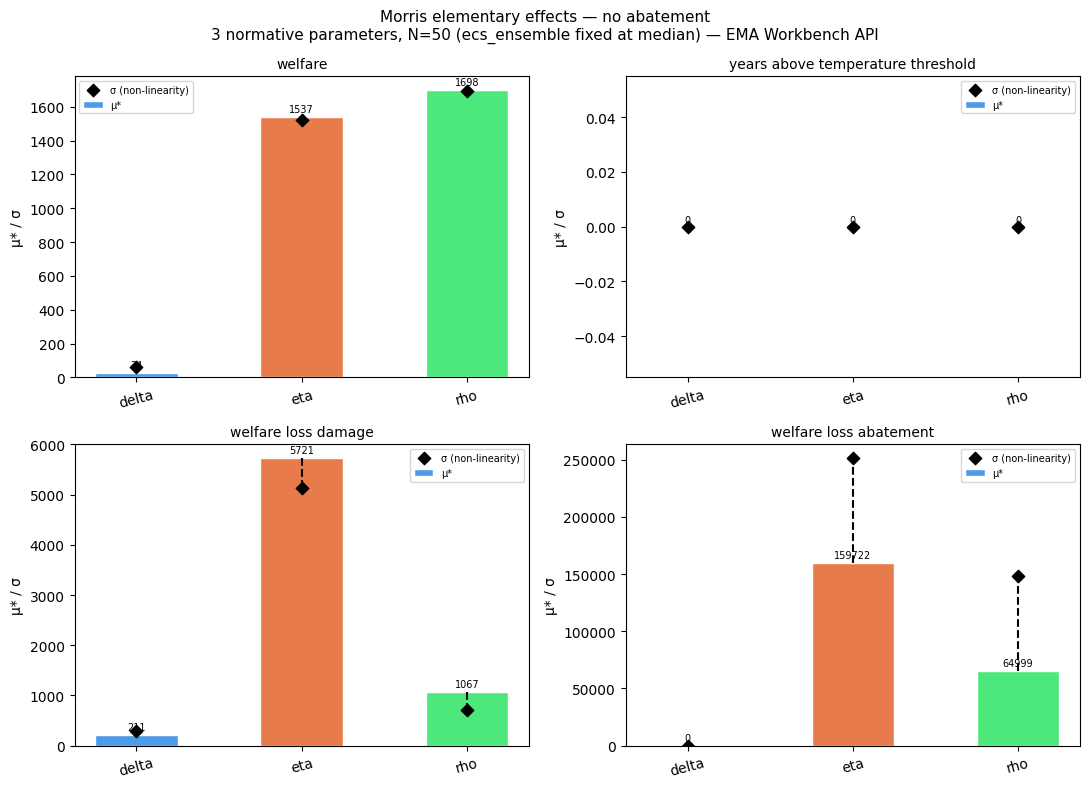

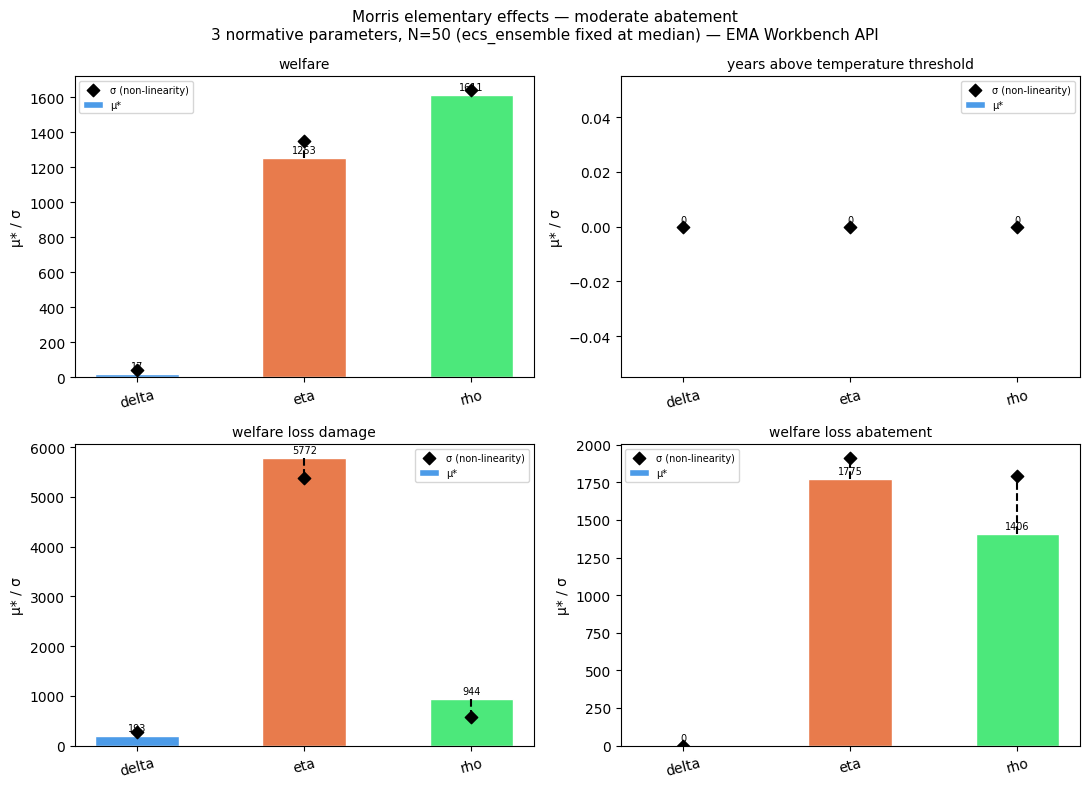

In [7]:
# Morris plots — identical to standard version
x = np.arange(len(PARAMS_MORRIS))

for pol in POLICY_NAMES:
    fig, axes = plt.subplots(2, 2, figsize=(11, 8))
    for ax, obj in zip(axes.flat, OBJECTIVES):
        Si      = morris_results[pol][obj]
        mu_star = Si['mu_star']
        sigma   = Si['sigma']
        colors  = ['#4C9BE8', '#E87B4C', '#4CE87B']
        bars = ax.bar(x, mu_star, color=colors, edgecolor='white', width=0.5, label='μ*')
        ax.scatter(x, sigma, color='black', zorder=5, s=40, marker='D',
                   label='σ (non-linearity)')
        for xi, (m, s) in enumerate(zip(mu_star, sigma)):
            ax.vlines(xi, m, s, colors='black', lw=1.5, linestyles='dashed')
        ax.set_xticks(x); ax.set_xticklabels(PARAMS_MORRIS, rotation=15)
        ax.set_title(obj.replace('_', ' '), fontsize=10)
        ax.set_ylabel('μ* / σ')
        ax.legend(fontsize=7)
        for bar, val in zip(bars, mu_star):
            ax.text(bar.get_x() + bar.get_width()/2, val + 0.01 * ax.get_ylim()[1],
                    f'{val:.0f}', ha='center', va='bottom', fontsize=7)
    fig.suptitle(
        f'Morris elementary effects — {pol.replace("_", " ")}\n'
        f'3 normative parameters, N={N_MORRIS} (ecs_ensemble fixed at median) — EMA Workbench API',
        fontsize=11)
    plt.tight_layout()
    plt.savefig(os.path.join(_PLOTS_DIR, f'a02api_morris_{pol}.png'), dpi=150, bbox_inches='tight')
    display(fig)
    plt.close(fig)

**How to read this plot — Morris μ\* and σ**

Each panel corresponds to one scalar outcome. Bars show **μ\*** (mean absolute elementary effect):
how much the outcome changes, on average, when that parameter is perturbed by a Δ step. Taller
bar = stronger influence on that outcome.

The black diamond **σ** (standard deviation of elementary effects) indicates non-linearity:
- If σ ≈ 0: the parameter has a consistent, additive effect everywhere in the parameter space.
- If σ >> μ\*: the parameter's effect is highly context-dependent — it matters a lot in some
  regions and almost nothing in others (strong non-linearity or interactions).

The dashed line connects bar top to diamond to make the μ\*–σ gap visual. 

---

## Reflection Questions

1. Physical vs. normative sensitivity. What do ET and Morris together reveal about which type of uncertainty dominates each outcome?

>For years_above_temperature_threshold, both methods agree: ET shows near-uniform importance (~0.25) across all four parameters, and Morris shows μ* ≈ 0 for all three normative parameters. Neither physical nor normative uncertainty clearly dominates this outcome, suggesting it is genuinely difficult to attribute at this sample size.

>For welfare-loss outcomes, normative uncertainty dominates. Morris identifies eta as the strongest driver of wl_damage and wl_abatement, followed by rho. For the aggregate welfare outcome, rho slightly leads eta under both policies, reflecting its direct role in time-discounting cumulative welfare. Physical uncertainty (ecs_ensemble) is the weakest driver across all outcomes in ET. The model's welfare structure is therefore more sensitive to value choices than to physical climate uncertainty.

2. Policy-conditional sensitivity. Which normative parameter's μ* changed most between the two policies? What does this imply for decision-making?

>For wl_damage and welfare, μ* values are broadly stable across policies. eta remains the dominant parameter for wl_damage with nearly identical μ*.  rho shows a modest decrease for wl_damage and welfare.

>The most dramatic change appears in wl_abatement for eta under no abatement and moderate abatement, but this should be interpreted cautiously: with ECR = 0, abatement costs are near-zero, making the outcome variance itself near-zero and the μ* estimates unreliable. Under moderate abatement, where wl_abatement is meaningful, eta and rho are both active drivers.

>The decision-making implication is that the normative sensitivity structure is robust to policy choice, eta dominates welfare-loss outcomes and rho leads aggregate welfare under both policies. These value disagreements cannot be resolved by choosing a different abatement level; they remain the central uncertainties regardless of policy.

